In [2]:
import pandas as pd
df = pd.read_csv("drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [4]:
(df == 0).sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


<Axes: xlabel='Drug'>

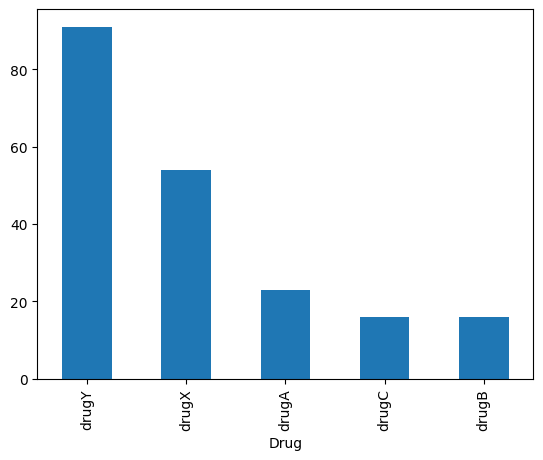

In [9]:
df['Drug'].value_counts().plot(kind='bar')

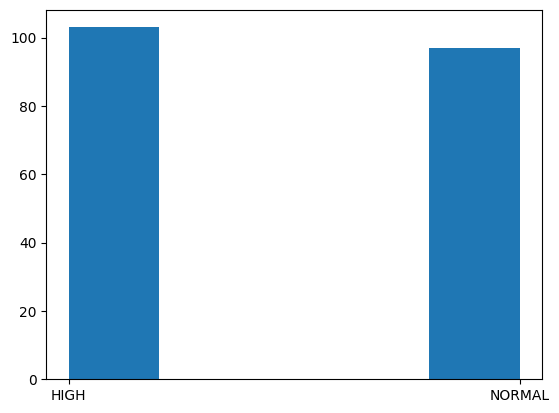

In [11]:
import matplotlib.pyplot as plt
plt.hist(df['Cholesterol'], bins = 5)
plt.show()

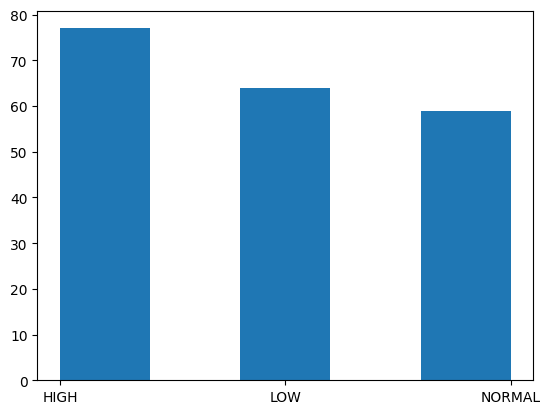

In [12]:
plt.hist(df['BP'], bins = 5)
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['Sex', 'BP', 'Cholesterol', 'Drug']
df_copy = df.copy()
df_copy[cols] = df_copy[cols].apply(le.fit_transform)
df_copy.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4


In [14]:
df_copy['Drug'].value_counts()

,count
Drug,
4,91
3,54
0,23
2,16
1,16


In [15]:
df['Drug'].value_counts()

,count
Drug,
drugY,91
drugX,54
drugA,23
drugC,16
drugB,16


In [16]:
df_copy['Cholesterol'].value_counts()

,count
Cholesterol,
0,103
1,97


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
x = df_copy.drop('Drug', axis = 1)
y = df_copy["Drug"]
x

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,  random_state = 42, stratify = y)

In [20]:
tree = DecisionTreeClassifier()
tree.fit(x_train, y_train)

DecisionTreeClassifier()

In [21]:
y_pred = tree.predict(x_test)
print(accuracy_score(y_test, y_pred))

0.975


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



In [27]:
forest = RandomForestClassifier(random_state = 42, n_estimators = 100, max_depth = 15)
forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=15, random_state=42)

In [28]:
pred = forest.predict(x_test)
print(accuracy_score(y_test, pred))

0.975


In [29]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40

